# From-scratch pretraining: reading the grid

Reads the records the factory writes -- `runs/*_result.json` -- whether they came from this
notebook, from `mlm_run.py`, or from an overnight `mlm_fleet.py` run across both cards. Nothing
here trains anything, so it is safe to re-run while a fleet is still going.

The question the grid exists to answer is **which axis binds**. Their v2 varied data at fixed
compute and got a flat line; that is what a compute-bound regime looks like, and it means a data
ladder cannot say anything until the step budget grows. The two panels below separate the axes so
the answer is measured rather than inferred.


In [1]:
import json, os, glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import mlm_api as factory

# The validated categorical palette, used in fixed slot order. Blue is always the first series,
# orange the second -- colour follows the entity, so a filter that drops a series never repaints
# the survivors. Text stays in ink colours; a coloured mark beside a label carries the identity.
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID = "#e6e5e1"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    # axisbelow keeps the grid behind the marks. Without it matplotlib draws gridlines over the
    # bars, which puts a recessive element on top of the data it is meant to sit behind.
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "lines.linewidth": 2.0, "lines.markersize": 8,
})

rows = factory.results('yor_*')
if not rows:
    print("No completed runs yet. Train the grid first:\n"
          "    python mlm_fleet.py --corpus yor --queue poc\n"
          "    python mlm_run.py  --corpus yor --random-init")
else:
    print(f"{len(rows)} completed runs")
    for r in sorted(rows, key=lambda r: (r["n_tokens"], r["steps"])):
        print(f'  {r["tag"]:<28} val {r["val_loss"]:.3f}  '
              f'{r["seconds"]/60:6.1f} min  {r["tokens_per_s"]/1e3:6.0f}k tok/s')


8 completed runs
  yor_2M_3k_s0                 val 5.701     1.9 min     442k tok/s
  yor_2M_6k_s0                 val 5.711     2.6 min     318k tok/s
  yor_2M_12k_s0                val 3.494     7.7 min     423k tok/s
  yor_2M_24k_s0                val 4.775    10.1 min     323k tok/s
  yor_32M_3k_s0                val 5.626     1.9 min     428k tok/s
  yor_32M_6k_s0                val 5.635     2.5 min     328k tok/s
  yor_32M_12k_s0               val 2.886     7.6 min     429k tok/s
  yor_32M_24k_s0               val 2.958    10.0 min     328k tok/s


## The results table

The table view is the accessible companion to every chart below: the same numbers, exactly,
without relying on colour or position to read them.

`random_loss` is `log(vocab_size)` -- the loss of a model that has learned nothing about the
language and predicts uniformly. A val loss near it means the run has not started learning.


In [2]:
import pandas as pd

df = pd.DataFrame(rows) if rows else pd.DataFrame()
if not df.empty:
    # The compute axis is tokens of updates, not steps. Steps are not comparable across batch
    # sizes -- 6,000 steps at batch 64 is half the work of 6,000 at batch 128 -- so a grid run
    # at two different batch sizes plots as four budgets instead of two unless this is derived.
    df["update_tokens"] = df["steps"] * df["batch"] * df["seq_len"]
    view = df[["tag", "n_tokens", "batch", "steps", "update_tokens", "passes", "val_loss",
               "random_loss", "seconds", "tokens_per_s", "store_dtype", "store_gb"]].copy()
    view["below_random"] = view["random_loss"] - view["val_loss"]
    view = view.sort_values(["n_tokens", "update_tokens", "batch"]).reset_index(drop=True)
    display(view.style.format({
        "n_tokens": "{:,.0f}", "steps": "{:,.0f}", "update_tokens": "{:,.0f}", "passes": "{:.1f}",
        "val_loss": "{:.3f}", "random_loss": "{:.2f}", "below_random": "{:+.3f}",
        "seconds": "{:.0f}", "tokens_per_s": "{:,.0f}", "store_gb": "{:.3f}"}))


,tag,n_tokens,batch,steps,update_tokens,passes,val_loss,random_loss,seconds,tokens_per_s,store_dtype,store_gb,below_random
0,yor_2M_6k_s0,"2,000,000",64,"6,000","49,152,000",24.6,5.711,9.68,155,"317,903",int16,0.004,+3.969
1,yor_2M_3k_s0,"2,000,000",128,"3,000","49,152,000",24.6,5.701,9.68,111,"441,696",int16,0.004,+3.979
2,yor_2M_24k_s0,"2,000,000",64,"24,000","196,608,000",98.3,4.775,9.68,608,"323,497",int16,0.004,+4.905
3,yor_2M_12k_s0,"2,000,000",128,"12,000","196,608,000",98.3,3.494,9.68,464,"423,287",int16,0.004,+6.187
4,yor_32M_6k_s0,"32,000,000",64,"6,000","49,152,000",1.5,5.635,9.68,150,"327,937",int16,0.064,+4.045
5,yor_32M_3k_s0,"32,000,000",128,"3,000","49,152,000",1.5,5.626,9.68,115,"427,938",int16,0.064,+4.054
6,yor_32M_24k_s0,"32,000,000",64,"24,000","196,608,000",6.1,2.958,9.68,599,"327,963",int16,0.064,+6.723
7,yor_32M_12k_s0,"32,000,000",128,"12,000","196,608,000",6.1,2.886,9.68,458,"429,147",int16,0.064,+6.795


## Which axis binds?

Two panels, one measure (validation MLM loss, lower is better), never two y-scales on one plot.

- **Left, the data axis:** loss against unique pretraining tokens, one line per step budget.
- **Right, the compute axis:** loss against optimizer steps, one line per token rung.

If the right panel moves while the left stays flat, the study is **compute-bound** -- extra
unique text has nothing to add until the step budget grows, and the data ladder in the proposal
is not yet measuring what it was meant to measure.


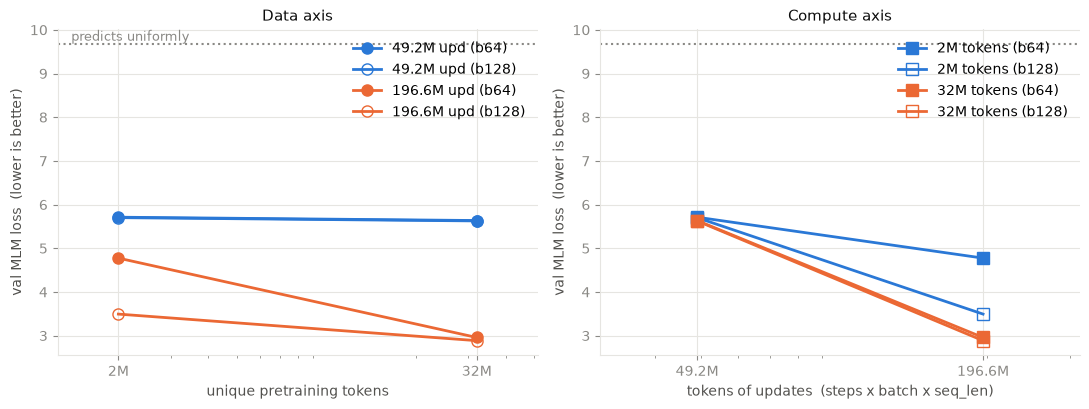

(read at batch 128; 8 runs total across 2 batch size(s))
at the largest step budget, varying data moves val loss by 0.608
at the largest data rung,  varying steps moves val loss by 2.740
-> compute-bound


In [3]:
if not df.empty:
    fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
    steps_seen = sorted(df["update_tokens"].unique())
    toks_seen = sorted(df["n_tokens"].unique())
    slots = [C1, C2, C3]
    fmt = factory.compact          # the same formatter the run names use

    # Batch shows up as marker fill, not as another colour: colour is reserved for the grid
    # axes, and the batch is a throughput choice rather than a variable of the experiment.
    batches = sorted(df["batch"].unique())
    fills = {b: ("full" if b == batches[0] else "none") for b in batches}

    # Left: data axis, one line per compute budget.
    for i, s in enumerate(steps_seen[:3]):
        for b in batches:
            sub = df[(df["update_tokens"] == s) & (df["batch"] == b)].sort_values("n_tokens")
            if len(sub):
                ax[0].plot(sub["n_tokens"], sub["val_loss"], "o-", color=slots[i],
                           fillstyle=fills[b],
                           label=f"{fmt(s)} upd" + (f" (b{b})" if len(batches) > 1 else ""))

    # Right: compute axis, one line per data rung.
    for i, n in enumerate(toks_seen[:3]):
        for b in batches:
            sub = df[(df["n_tokens"] == n) & (df["batch"] == b)].sort_values("update_tokens")
            if len(sub):
                ax[1].plot(sub["update_tokens"], sub["val_loss"], "s-", color=slots[i],
                           fillstyle=fills[b],
                           label=f"{fmt(n)} tokens" + (f" (b{b})" if len(batches) > 1 else ""))

    # The learned-nothing reference. Recessive, labelled in ink, not a series colour.
    rl = float(df["random_loss"].iloc[0])
    for a in ax:
        a.axhline(rl, ls=":", lw=1.5, color=MUTED)
        a.set_ylabel("val MLM loss  (lower is better)")
        a.legend(loc="upper right")
    ax[0].text(0.02, rl, " predicts uniformly", transform=ax[0].get_yaxis_transform(),
               va="bottom", ha="left", color=MUTED, fontsize=9)

    ax[0].set_xlabel("unique pretraining tokens")
    ax[0].set_title("Data axis")
    ax[1].set_xlabel("tokens of updates  (steps x batch x seq_len)")
    ax[1].set_title("Compute axis")

    # A ladder is a handful of discrete rungs, so tick exactly on them. Letting a log axis choose
    # its own ticks put "3 x 10^5" next to "100k" on the same axis and printed scientific
    # notation for the minor ticks; explicit ticks also keep every label in one unit system.
    for a, vals in ((ax[0], toks_seen), (ax[1], steps_seen)):
        a.set_xscale("log")
        a.set_xticks(vals)
        a.set_xticklabels([fmt(v) for v in vals])
        a.xaxis.set_minor_formatter(mticker.NullFormatter())
        a.set_xlim(min(vals) / 1.6, max(vals) * 1.6)
    fig.tight_layout()
    plt.show()

    # State the reading in words, from the numbers, rather than leaving it to the eye.
    if len(toks_seen) > 1 and len(steps_seen) > 1:
        # Read the verdict off ONE batch size. Mixing them here compares a b64 cell against a
        # b128 cell and charges the difference to the data axis, which is not what moved.
        latest = df[df["batch"] == batches[-1]]
        top = latest[latest["update_tokens"] == steps_seen[-1]].sort_values("n_tokens")
        rng_data = top["val_loss"].max() - top["val_loss"].min()
        big = latest[latest["n_tokens"] == toks_seen[-1]].sort_values("update_tokens")
        rng_comp = big["val_loss"].max() - big["val_loss"].min()
        print(f"(read at batch {batches[-1]}; {len(df)} runs total across "
              f"{len(batches)} batch size(s))")
        print(f"at the largest step budget, varying data moves val loss by {rng_data:.3f}")
        print(f"at the largest data rung,  varying steps moves val loss by {rng_comp:.3f}")
        print("-> compute-bound" if rng_comp > 2 * rng_data else
              "-> data matters at least as much as compute here")


## Training curves

One line per grid cell, from the JSONL each run logged as it went. Colour carries the data rung
and dash carries the step budget -- a composite encoding, so four cells never need four hues.


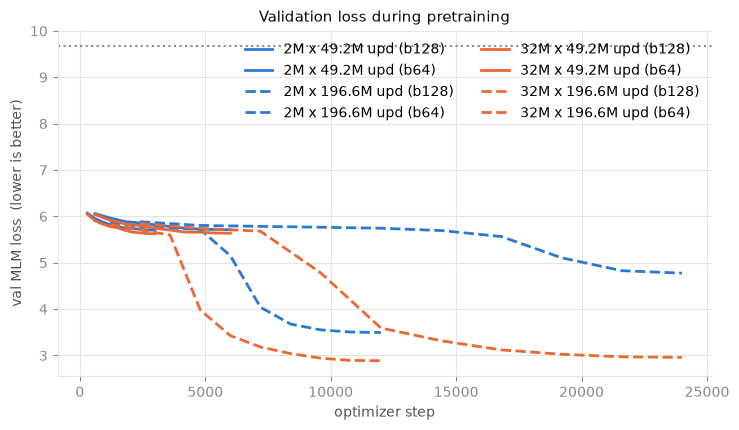

In [4]:
if not df.empty:
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    toks_seen = sorted(df["n_tokens"].unique())
    dashes = {s: d for s, d in zip(sorted(df["update_tokens"].unique()), ["-", "--", ":"])}
    colors = {n: c for n, c in zip(toks_seen, [C1, C2, C3])}

    for _, r in df.sort_values(["n_tokens", "update_tokens"]).iterrows():
        h = factory.curve(r["tag"])
        if not h:
            continue
        xs = [p["step"] for p in h]
        ys = [p["val"]["loss"] for p in h]
        ax.plot(xs, ys, dashes.get(r["update_tokens"], "-"),
                color=colors.get(r["n_tokens"], C1),
                label=f'{factory.compact(r["n_tokens"])} x '
                      f'{factory.compact(r["update_tokens"])} upd (b{r["batch"]})')

    ax.axhline(float(df["random_loss"].iloc[0]), ls=":", lw=1.5, color=MUTED)
    ax.set_xlabel("optimizer step")
    ax.set_ylabel("val MLM loss  (lower is better)")
    ax.set_title("Validation loss during pretraining")
    ax.legend(loc="upper right", ncols=2)
    fig.tight_layout()
    plt.show()


## What the runs cost, and what the full study would

`tokens_per_s` is measured, not modelled. The projection to AfriBERTa scale uses the same
hidden^2 x depth rule the POC used, which is honest for "does this fit a weekend" and not for
"is this 3.2 or 3.4 hours".

Note the wall-clock caveat: these are **GPU-hours**. Run through `mlm_fleet.py` on both cards and
elapsed time is roughly half of them.


In [5]:
if not df.empty:
    cost = df[["tag", "batch", "seconds", "tokens_per_s", "store_dtype", "store_gb"]].copy()
    cost["minutes"] = cost["seconds"] / 60
    display(cost[["tag", "batch", "minutes", "tokens_per_s", "store_dtype", "store_gb"]]
            .sort_values("minutes")
            .style.format({"minutes": "{:.1f}", "tokens_per_s": "{:,.0f}",
                           "store_gb": "{:.3f}"}))

    med = float(df["tokens_per_s"].median())
    print(f"\nmedian throughput {med/1e3:.0f}k tok/s at preset {df['preset'].iloc[0]!r}")

    # The full-study projection, at AfriBERTa scale, 12 passes per rung.
    PASSES, BATCH, SEQ = 12, int(df["batch"].iloc[0]), int(df["seq_len"].iloc[0])
    scale = (768 / 512) ** 2 * (12 / 8)
    eff = med / scale
    print(f"at afriberta scale ({scale:.1f}x cost/token): {eff/1e3:.0f}k tok/s\n")
    print(f'{"rung":>13}{"tokens seen":>16}{"GPU-h":>9}{"2-card h":>10}')
    total = 0.0
    for n in (4_000_000, 16_000_000, 64_000_000):
        h = n * PASSES / eff / 3600
        total += h
        print(f"{n:>13,}{n*PASSES:>16,}{h:>9.2f}{h/2:>10.2f}")
    print(f'{"per language":>13}{"":>16}{total:>9.2f}{total/2:>10.2f}')


,tag,batch,minutes,tokens_per_s,store_dtype,store_gb
2,yor_2M_3k_s0,128,1.9,"441,696",int16,0.004
6,yor_32M_3k_s0,128,1.9,"427,938",int16,0.064
7,yor_32M_6k_s0,64,2.5,"327,937",int16,0.064
3,yor_2M_6k_s0,64,2.6,"317,903",int16,0.004
4,yor_32M_12k_s0,128,7.6,"429,147",int16,0.064
0,yor_2M_12k_s0,128,7.7,"423,287",int16,0.004
5,yor_32M_24k_s0,64,10.0,"327,963",int16,0.064
1,yor_2M_24k_s0,64,10.1,"323,497",int16,0.004



median throughput 376k tok/s at preset 'poc'
at afriberta scale (3.4x cost/token): 111k tok/s

         rung     tokens seen    GPU-h  2-card h
    4,000,000      48,000,000     0.12      0.06
   16,000,000     192,000,000     0.48      0.24
   64,000,000     768,000,000     1.92      0.96
 per language                     2.52      1.26


## What the wider token store costs

The factory sizes the resident token stream to the vocabulary: `int16` for a 16k BPE, `int32`
when a vocabulary needs more than 32,768 ids -- which is every multilingual checkpoint (mBERT is
about 120k, XLM-R about 250k). The POC held its stream as `int64`, so the narrow store is a 4x
saving on that array for identical batches.

The measurement below comes from `store_bench.py`, which holds corpus, model, batch shape, and
seed fixed and changes only the width. Re-generate it with:

```
python store_bench.py --dataset wikitext103 --model gpt --repeat 5 --json store_bench_gpt.json
```


,width,bytes/token,store GB,peak GB,step tok/s
0,int16,2,0.248,9.070,"772,664"
1,int32,4,0.495,9.316,"773,705"


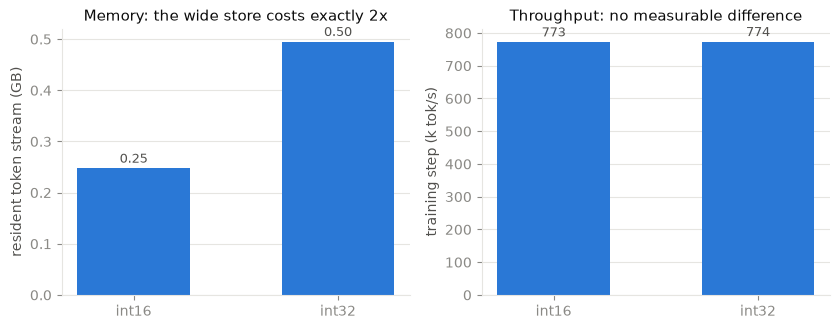

In [6]:
bench_path = "store_bench_gpt.json"
if os.path.exists(bench_path):
    with open(bench_path, encoding="utf-8") as f:
        b = json.load(f)
    br = {r["store_dtype"]: r for r in b["rows"]}

    tbl = pd.DataFrame([{
        "width": k,
        "bytes/token": v["bytes_per_token"],
        "store GB": v["store_bytes"] / 1e9,
        "peak GB": v["peak_bytes"] / 1e9,
        "step tok/s": v["step_tok_s"],
    } for k, v in br.items()])
    display(tbl.style.format({"store GB": "{:.3f}", "peak GB": "{:.3f}",
                              "step tok/s": "{:,.0f}"}))

    fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.4))
    names = list(br)
    # Magnitude against a categorical axis: one hue, identity read off the axis labels, so no
    # legend is needed and none is drawn.
    ax[0].bar(names, [br[k]["store_bytes"] / 1e9 for k in names], color=C1, width=0.55)
    ax[0].set_ylabel("resident token stream (GB)")
    ax[0].set_title("Memory: the wide store costs exactly 2x")
    ax[1].bar(names, [br[k]["step_tok_s"] / 1e3 for k in names], color=C1, width=0.55)
    ax[1].set_ylabel("training step (k tok/s)")
    ax[1].set_title("Throughput: no measurable difference")
    for a in ax:
        a.grid(axis="x", visible=False)
    for a, vals in ((ax[0], [br[k]["store_bytes"] / 1e9 for k in names]),
                    (ax[1], [br[k]["step_tok_s"] / 1e3 for k in names])):
        for x, v in zip(names, vals):
            a.annotate(f"{v:,.2f}" if v < 10 else f"{v:,.0f}", (x, v),
                       textcoords="offset points", xytext=(0, 4),
                       ha="center", color=INK2, fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print(f"{bench_path} not found -- run store_bench.py with --json to generate it.")


## Reading this run

1. **Which axis binds.** If the compute panel moves and the data panel does not, the ladder in
   the proposal cannot answer its question at this budget. Say so, and report it -- a measured
   "we were compute-bound" is a finding, not a failure.
2. **The random-init control.** It is not in this notebook, because it is a fine-tuning result,
   not a pretraining one. It stays in the POC notebook where the SIB-200 harness lives. Whatever
   the pretrained cells score above it is what pretraining bought; a gain inside the seed spread
   is not a gain.
3. **Seeds.** Everything above is one seed unless the grid was run with more. Before quoting any
   gap, run `python mlm_fleet.py --corpus yor --queue seeds` and check the spread is smaller than
   the effect.
